# Round 0: Emeralds and Tomatoes

## Table Of Contents:
* [Setup](#setup)
* [Data Loading](#data-loading)
* [Descriptive Statistics](#descriptive-statistics)
* [Mid Price Statistics](#mid-price-statistics)
* [Order Book Spread](#order-book-spread)
* [Trade Analysis & Volume](#trade-analysis--volume)
* [Order Book Depth Visualisation](#order-book-depth-visualisation)
* [Stationarity and Autocorrelation (ACF / PACF)](#stationarity-and-autocorrelation-acf--pacf)
* [EMERALDS: Mean-Reversion Analysis](#emeralds-mean-reversion-analysis)
* [TOMATOES: Trend vs Mean-Reversion (VWAP & Moving Averages)](#tomatoes-trend-vs-mean-reversion-vwap--moving-averages)
* [Order Book Imbalance (OBI) & Microstructure](#order-book-imbalance-obi--microstructure)

## Setup

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import prosperity4
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)

plt.style.use("dark_background")
sns.set_palette("pastel")


## Data Loading

In [2]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round0" / "data"
ROUND_NUM = 0
DAYS = [-2, -1]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (40000, 17)
Trades Shape : (1219, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,900,NaN,NaN,TOMATOES,XIRECS,5008.0,2,-2
1,1700,NaN,NaN,TOMATOES,XIRECS,5006.0,3,-2
2,4000,NaN,NaN,EMERALDS,XIRECS,10008.0,7,-2
3,4100,NaN,NaN,TOMATOES,XIRECS,5002.0,3,-2
4,5200,NaN,NaN,EMERALDS,XIRECS,9992.0,5,-2


## Descriptive Statistics

First, let's identify what products are being traded in this round and get some basic statistics.

In [ ]:
products = prices_df["product"].unique()
print("Available Products:", products)


summary = prices_df.groupby("product").agg(
    mid_mean=("mid_price", "mean"),
    mid_std=("mid_price", "std"),
    mid_min=("mid_price", "min"),
    mid_max=("mid_price", "max"),
    avg_bid_vol=("bid_volume_1", "mean"),
    avg_ask_vol=("ask_volume_1", "mean"),
).round(2)
print("\nProduct Summary:")
print(summary)

Available Products: <StringArray>
['EMERALDS', 'TOMATOES']
Length: 2, dtype: str

Product Summary:
          mid_mean  mid_std  mid_min  mid_max  avg_bid_vol  avg_ask_vol
product                                                                
EMERALDS  10000.00     0.72   9996.0  10004.0        12.46        12.46
TOMATOES   4992.76    19.75   4946.5   5036.0         7.44         7.45


## Mid Price Statistics

We analyze how the `mid_price` for each product changes over time. We will use a continuous timestamp mapping to plot day `-2` and `-1` consecutively.

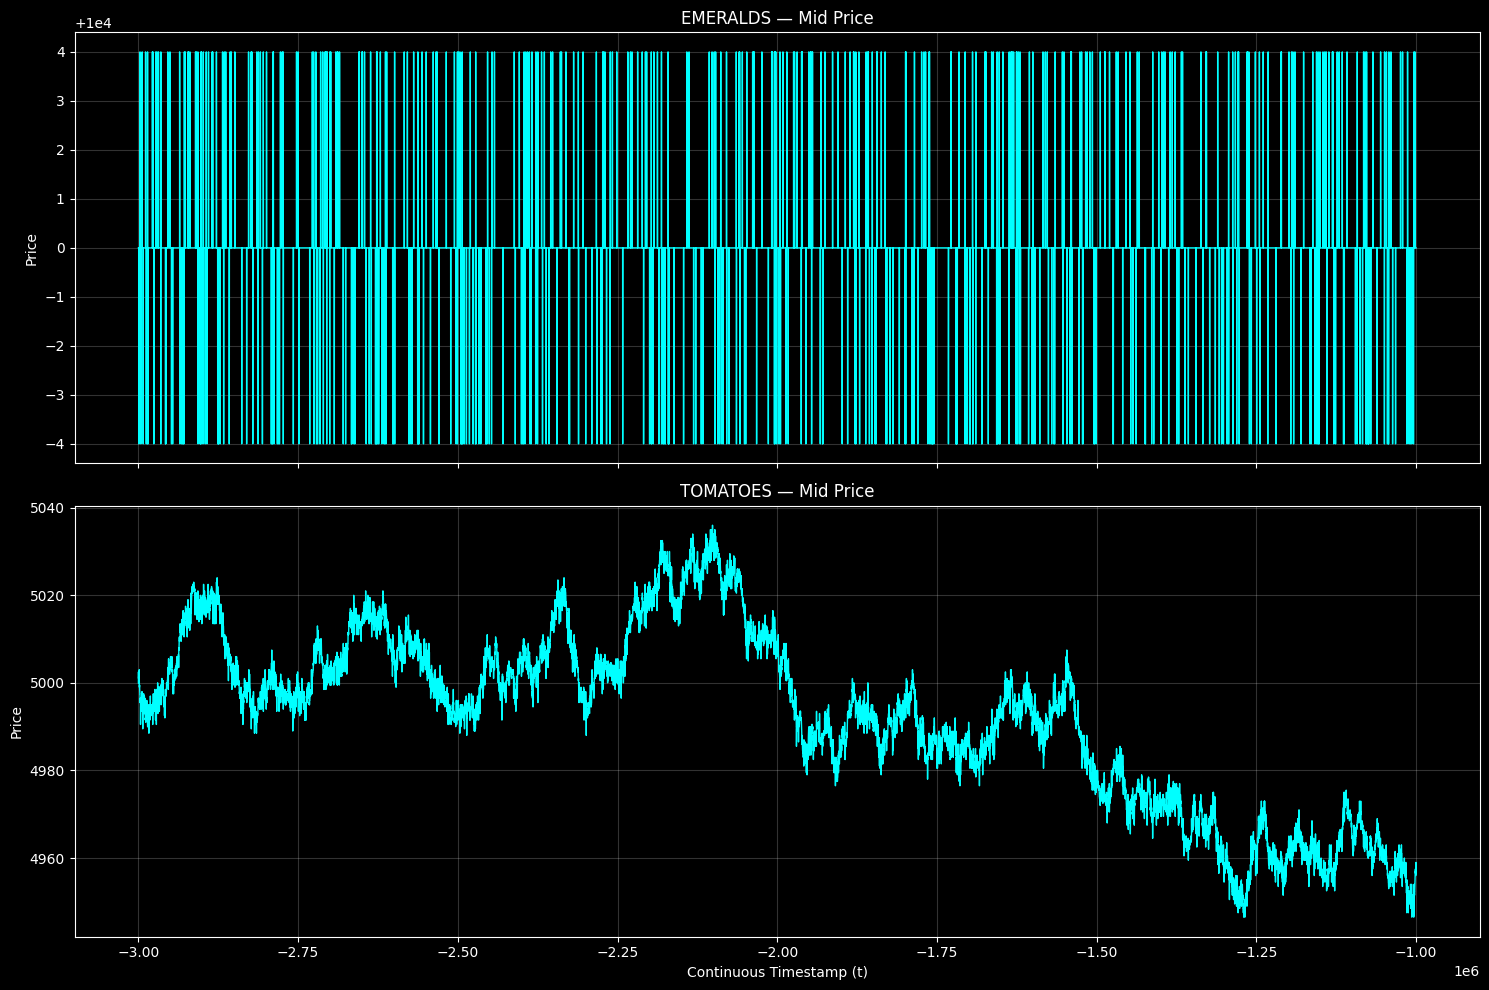

In [ ]:
prices_continuous = convert_timestamp(prices_df)

# Spread is just the difference between the highest bid and the lowest ask
prices_continuous["spread"] = prices_continuous["ask_price_1"] - prices_continuous["bid_price_1"]

# Individual subplots
fig, axes = plt.subplots(len(products), 1, figsize=(15, 5 * len(products)), sharex=True)
if len(products) == 1:
    axes = [axes]
for ax, prod in zip(axes, products):
    d = prices_continuous[prices_continuous["product"] == prod]
    
    # Here the mid price column is given in the csv file and it's the mid value between highest bid and lowest ask
    # It corresponds to the fair value for EMERALDS
    ax.plot(d["t"], d["mid_price"], color="cyan", linewidth=1)
    ax.set_title(f"{prod} — Mid Price", fontsize=12)
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.2)
plt.xlabel("Continuous Timestamp (t)")
plt.tight_layout()
plt.show()


## Order Book Spread

The bid-ask spread is an indicator of the product's liquidity and market maker margins. A tighter spread often means a highly liquid market.

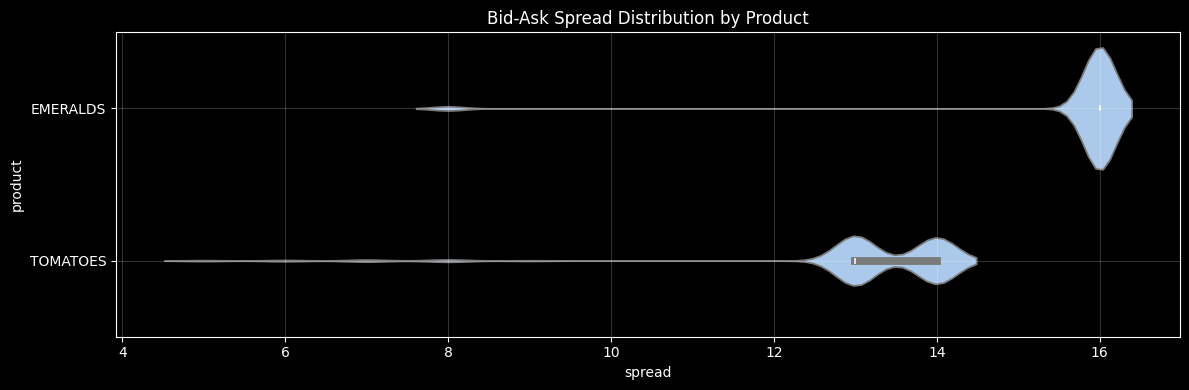

            count   mean   std  min   25%   50%   75%   max
product                                                    
EMERALDS  20000.0  15.74  1.42  8.0  16.0  16.0  16.0  16.0
TOMATOES  20000.0  13.02  1.75  5.0  13.0  13.0  14.0  14.0


In [ ]:
plt.figure(figsize=(12, 4))
sns.violinplot(data=prices_continuous, y="product", x="spread")
plt.title("Bid-Ask Spread Distribution by Product")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Here we're printing the basic statistics for the spread for each product
spread_stats = prices_continuous.groupby("product")["spread"].describe().round(2)
print(spread_stats)

## Trade Analysis & Volume

We map the executed trades over the price line to see if trades occur closer to local maximums or minimums.

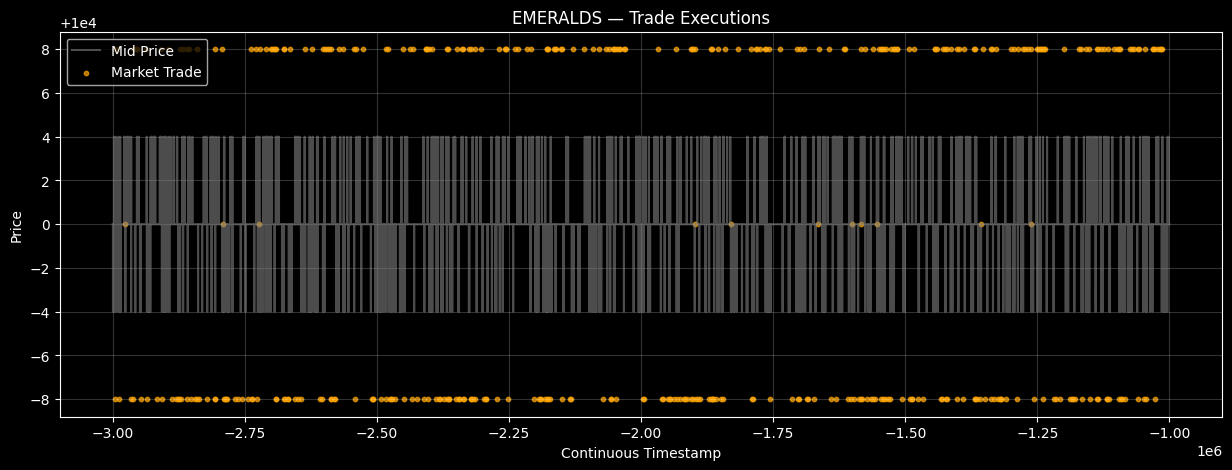

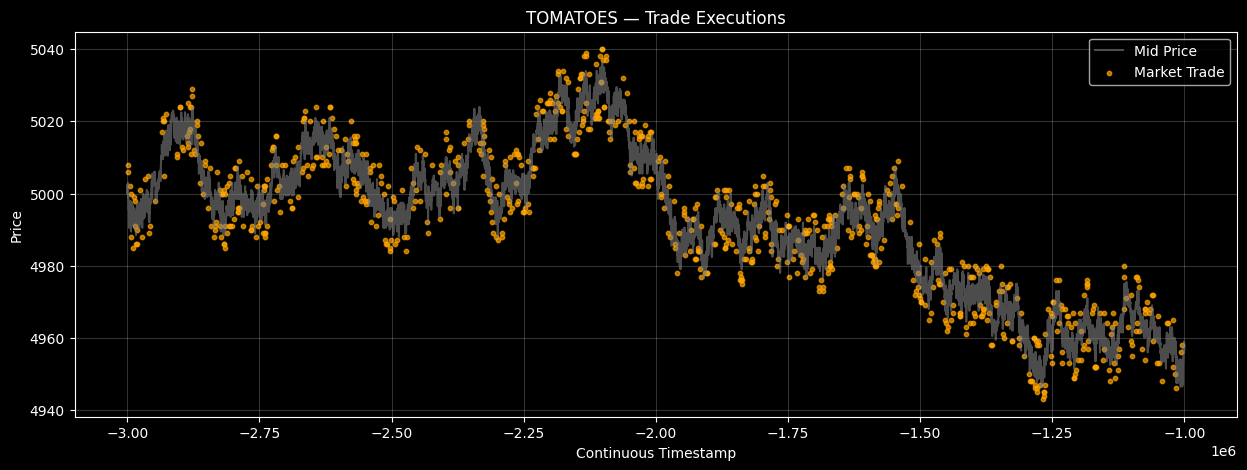

In [ ]:
# As we did before for the prices, we're converting the original dataframe in a new one where the "index" is the timestep instead of days
trades_continuous = convert_timestamp(trades_df)
for prod in products:

    # prod_prices and prod_trades are used to plot later on, it's simply selecting the current product's data
    prod_prices = prices_continuous[prices_continuous["product"] == prod]
    prod_trades = trades_continuous[trades_continuous["symbol"] == prod]
    if len(prod_trades) == 0:
        print(f"No trades found for {prod}")
        continue
    plt.figure(figsize=(15, 5))

    # Plotting the price chart for the given product
    plt.plot(prod_prices["t"], prod_prices["mid_price"],
                label="Mid Price", color="grey", alpha=0.6)
    
    # Plotting the trades as an orange dot for a given product
    plt.scatter(prod_trades["t"], prod_trades["price"],
                color="orange", s=10, label="Market Trade", alpha=0.7)
    plt.title(f"{prod} — Trade Executions")
    plt.xlabel("Continuous Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

## Order Book Depth Visualisation

Visualising the 3-level depth of the order book for both the bid and ask sides. It is helpful to determine whether the volume accumulates far from or near the mid price. Here we examine the last 200 ticks of the dataset.

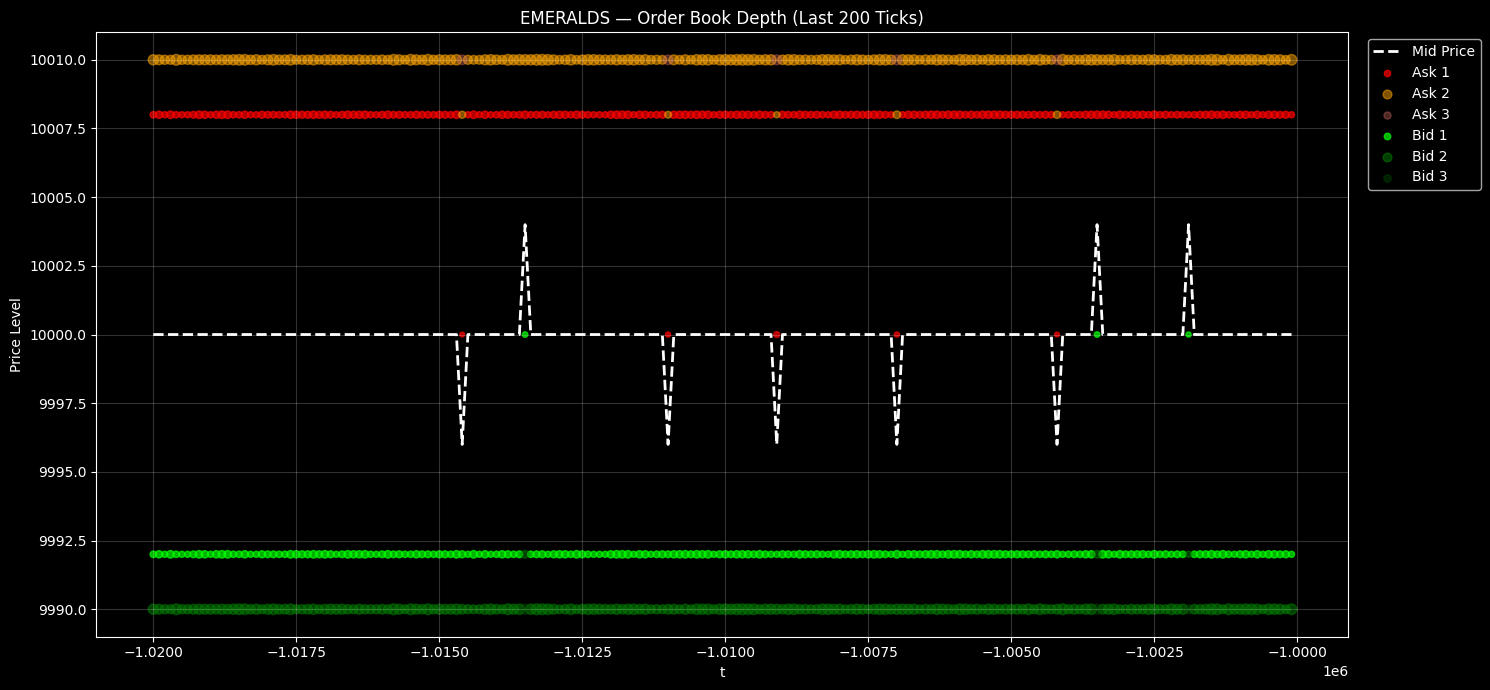

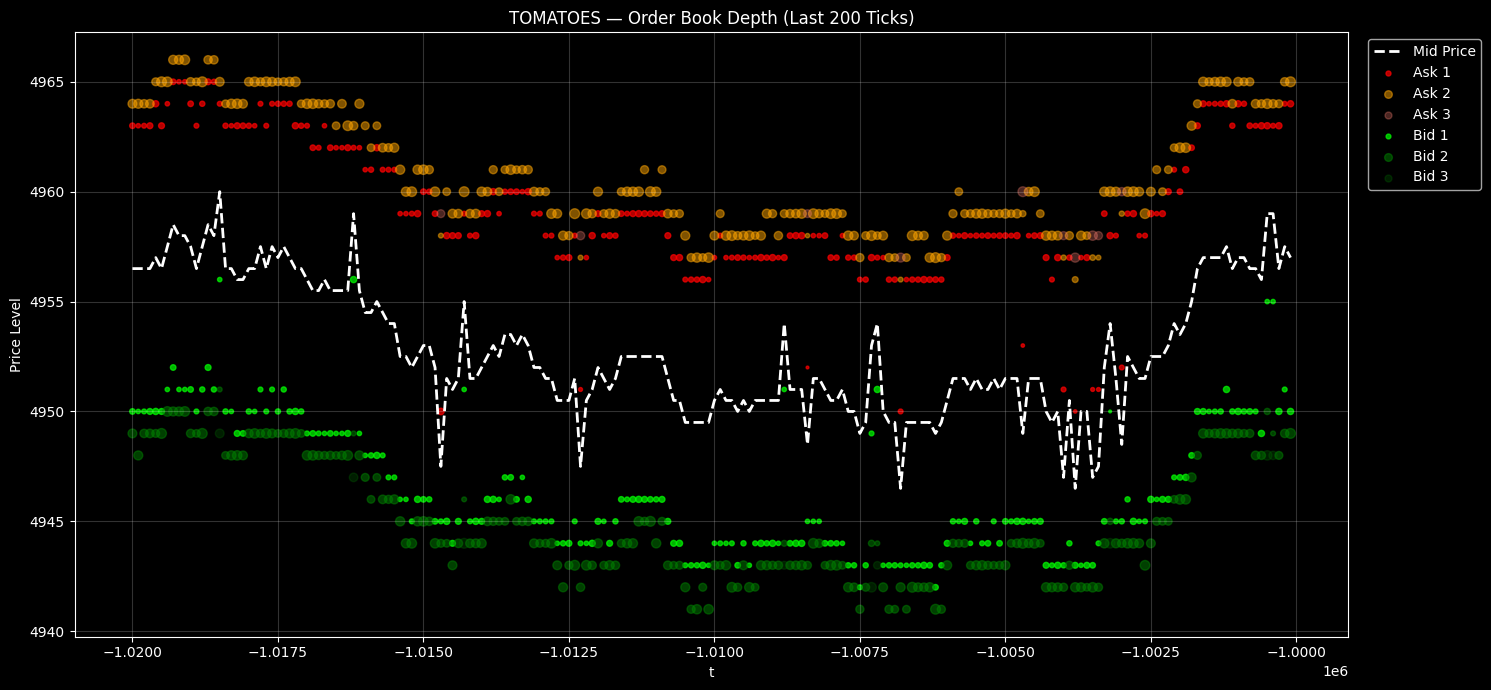

In [ ]:
# levels is a list of tuple containing price, volume, color, label, alpha
levels = [
    ("ask_price_1", "ask_volume_1", "red",       "Ask 1", 0.7),
    ("ask_price_2", "ask_volume_2", "orange",    "Ask 2", 0.5),
    ("ask_price_3", "ask_volume_3", "salmon",    "Ask 3", 0.3),
    ("bid_price_1", "bid_volume_1", "lime",      "Bid 1", 0.7),
    ("bid_price_2", "bid_volume_2", "green",     "Bid 2", 0.5),
    ("bid_price_3", "bid_volume_3", "darkgreen", "Bid 3", 0.3),
]

for prod in products:

    # Sample is just the last 200 observations of each product
    sample = prices_continuous[prices_continuous["product"] == prod].iloc[-200:].copy()
    
    if sample.empty:
        continue
    
    plt.figure(figsize=(15, 7))
    
    # Price plot
    plt.plot(sample["t"], sample["mid_price"], color="white",
             label="Mid Price", linestyle="--", linewidth=2)
    
    # for each of the tuple in the levels list do a scatter plot with the style contained in the list
    for p_col, v_col, col, lbl, alp in levels:

        # If in the sample dataframe there's a column named as, for example, "ask_price_1", plot those order book values
        if p_col in sample.columns and not sample[p_col].isna().all():
            
            # Size of the dot depends on the order size
            sizes = sample[v_col].fillna(0) * 2 if v_col in sample.columns else 20
            plt.scatter(sample["t"], sample[p_col],
                        s=sizes, color=col, alpha=alp, label=lbl)
    plt.title(f"{prod} — Order Book Depth (Last 200 Ticks)")
    plt.xlabel("t")
    plt.ylabel("Price Level")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


## Stationarity and Autocorrelation (ACF / PACF)

We want to know if the asset prices are **mean-reverting** (stationary) or **trending** (random walk / non-stationary). 
- If an asset is highly mean-reverting, we can consider a **Market Making** strategy.
- If an asset exhibits momentum, we can consider a **Trend Following** strategy.

Let's check the Autocorrelation Function (ACF) of the price differences (returns) to see if past returns predict future returns.

EMERALDS - ADF Statistic: -138.8409, p-value: 0.0000
 -> EMERALDS appears to be STATIONARY (Mean-Reverting).


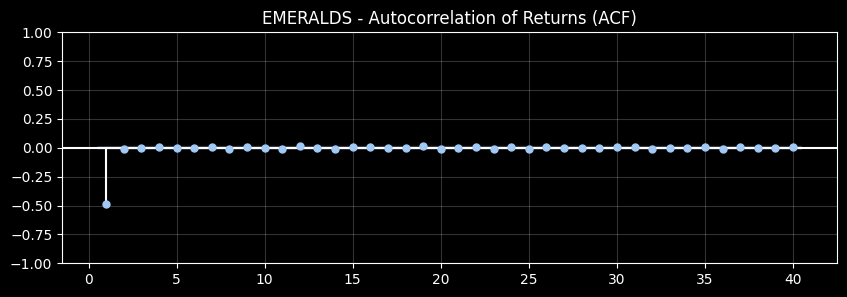

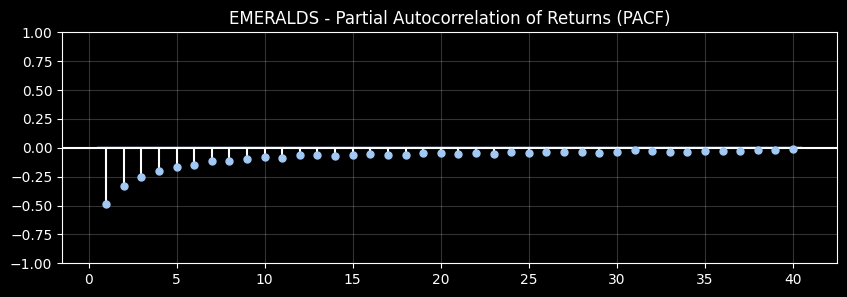

--------------------------------------------------------------------------------
TOMATOES - ADF Statistic: -1.3340, p-value: 0.6135
 -> TOMATOES appears to be NON-STATIONARY (Trending/Random Walk).


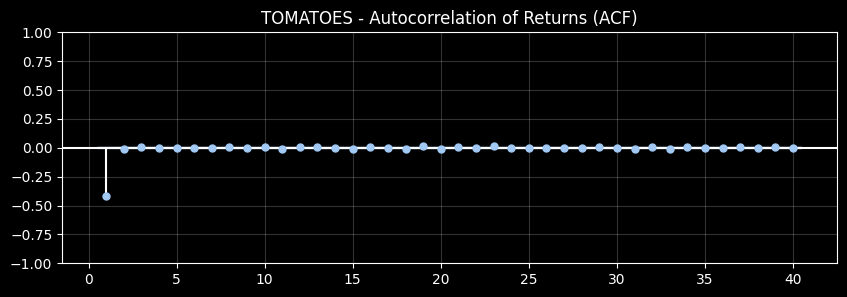

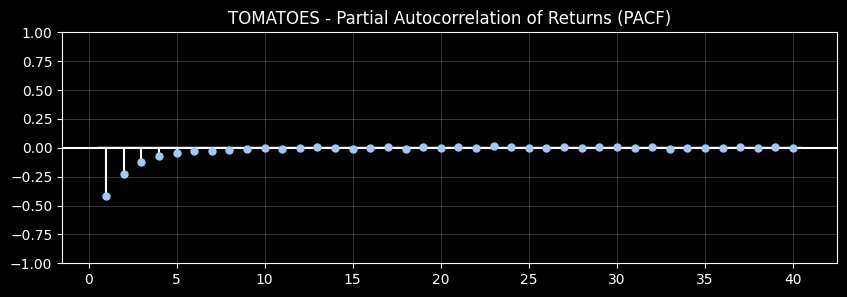

--------------------------------------------------------------------------------


In [ ]:
if prices_df is not None:
    for prod in products:

        
        prod_data = prices_continuous[prices_continuous['product'] == prod]['mid_price'].dropna().values
        
        # Perform Augmented Dickey-Fuller test
        adf_result = adfuller(prod_data)
        print(f'{prod} - ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}')
        if adf_result[1] < 0.05:
            print(f' -> {prod} appears to be STATIONARY (Mean-Reverting).')
        else:
            print(f' -> {prod} appears to be NON-STATIONARY (Trending/Random Walk).')


        # Calculate returns (diff)
        returns = np.diff(prod_data)

        # Plot ACF & PACF
        plt.figure(figsize=(10, 3))
        # Use a max lag of 40 to see short-term momentum or mean-reversion
        plot_acf(returns, lags=40, zero=False, alpha=0.05, title=f'{prod} - Autocorrelation of Returns (ACF)', ax=plt.gca())
        plt.grid(True, alpha=0.2)
        
        plt.figure(figsize=(10, 3))
        plot_pacf(returns, lags=40, zero=False, alpha=0.05, title=f'{prod} - Partial Autocorrelation of Returns (PACF)', ax=plt.gca())
        plt.grid(True, alpha=0.2)
        
        plt.show()
        print('-'*80)

## EMERALDS: Mean-Reversion Analysis

`EMERALDS` is a stable asset pegged at `10000`, with variations caused by market microstructure noise.

Let's verify if the price heavily clusters around `10000`, which suggests a pure **Market Making** or **Fading** strategy (buying when < 10000, selling when > 10000).

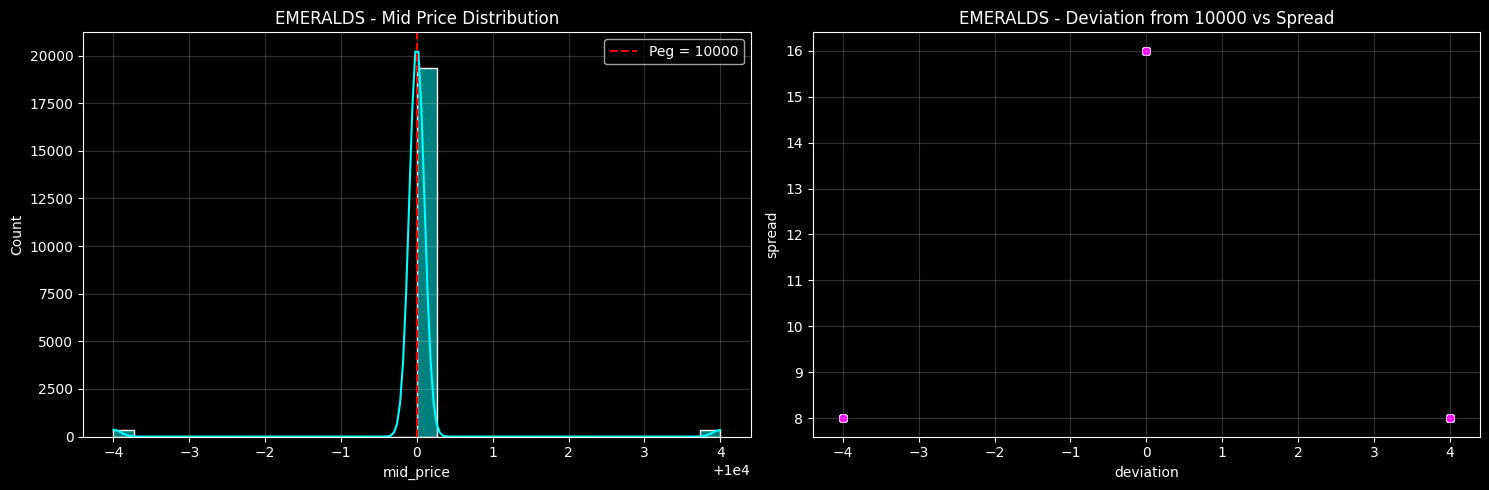

EMERALDS Deviation Stats:
count    20000.00000
mean        -0.00240
std          0.72334
min         -4.00000
25%          0.00000
50%          0.00000
75%          0.00000
max          4.00000
Name: deviation, dtype: float64

Percentage of time mid_price is exactly 10000: 96.73%


In [12]:
emeralds_data = prices_continuous[prices_continuous['product'] == 'EMERALDS'].copy()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Price Distribution
sns.histplot(emeralds_data['mid_price'], bins=30, ax=ax[0], color='cyan', kde=True)
ax[0].set_title('EMERALDS - Mid Price Distribution')
ax[0].axvline(10000, color='red', linestyle='--', label='Peg = 10000')
ax[0].legend()
ax[0].grid(True, alpha=0.2)

# Deviation from mean vs Spread
emeralds_data['deviation'] = emeralds_data['mid_price'] - 10000
sns.scatterplot(data=emeralds_data, x='deviation', y='spread', ax=ax[1], alpha=0.3, color='magenta')
ax[1].set_title('EMERALDS - Deviation from 10000 vs Spread')
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Quick profitability analysis
dev_stats = emeralds_data['deviation'].describe()
print('EMERALDS Deviation Stats:')
print(dev_stats)
print(f'\nPercentage of time mid_price is exactly 10000: {(emeralds_data["mid_price"] == 10000).mean()*100:.2f}%')

## TOMATOES: Trend vs Mean-Reversion (VWAP & Moving Averages)

If `TOMATOES` is non-stationary, it might trend over the day. We can use Moving Averages (e.g., Short MA vs Long MA crossover) and VWAP to identify trend direction. 
- **VWAP (Volume Weighted Average Price)**: If the current price is above VWAP, the market is generally bullish on the asset.
- **SMA Crossover**: Typical momentum signal.

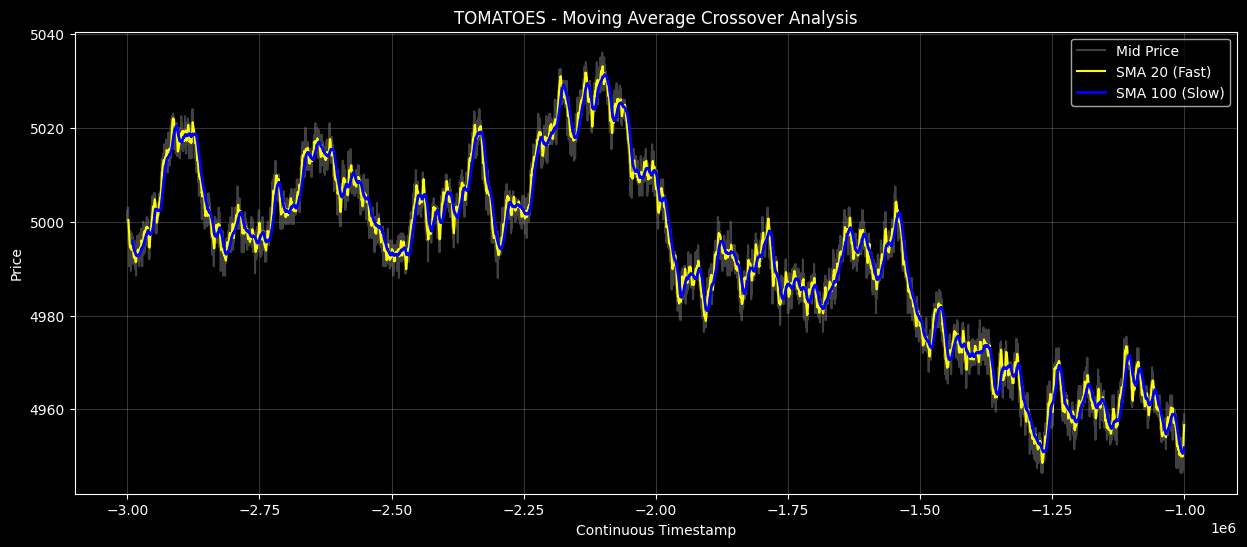

In [17]:
if 'TOMATOES' in products:
    tom_data = prices_continuous[prices_continuous['product'] == 'TOMATOES'].copy()
    
    # Calculate SMAs
    tom_data['SMA_20'] = tom_data['mid_price'].rolling(window=20).mean()
    tom_data['SMA_100'] = tom_data['mid_price'].rolling(window=100).mean()
    
    plt.figure(figsize=(15, 6))
    plt.plot(tom_data['t'], tom_data['mid_price'], label='Mid Price', color='grey', alpha=0.5)
    plt.plot(tom_data['t'], tom_data['SMA_20'], label='SMA 20 (Fast)', color='yellow', linewidth=1.5)
    plt.plot(tom_data['t'], tom_data['SMA_100'], label='SMA 100 (Slow)', color='blue', linewidth=2)
    
    plt.title('TOMATOES - Moving Average Crossover Analysis')
    plt.xlabel('Continuous Timestamp')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

## Order Book Imbalance (OBI) & Microstructure

The **Order Book Imbalance (OBI)** measures the buying vs selling pressure resting in the limit order book.
`OBI = (Bid_Volume - Ask_Volume) / (Bid_Volume + Ask_Volume)`
- **OBI > 0**: More buyers than sellers. Price might go UP.
- **OBI < 0**: More sellers than buyers. Price might go DOWN.

If OBI has high predictive power for the next tick's return, we can build an **Order Book Imbalance Strategy**.

EMERALDS - Correlation (OBI vs Next Return): 0.6306 (p-value: 0.0000)


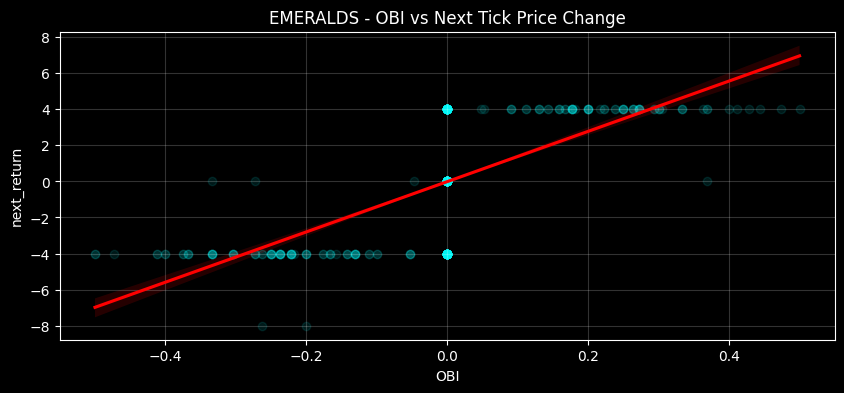

--------------------------------------------------------------------------------
TOMATOES - Correlation (OBI vs Next Return): 0.3258 (p-value: 0.0000)


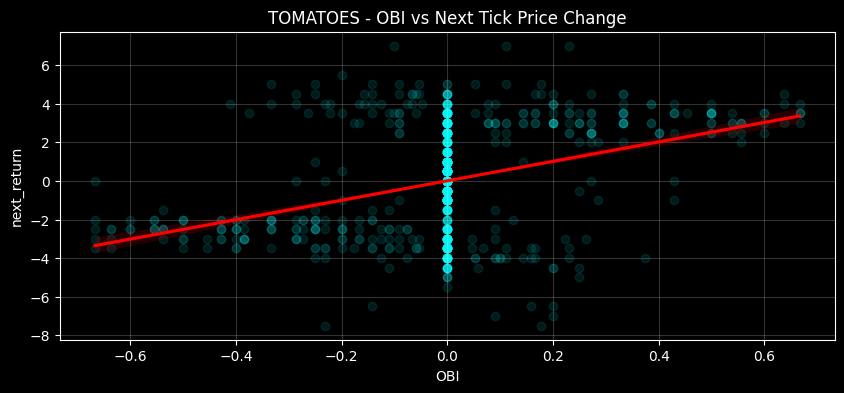

--------------------------------------------------------------------------------


In [ ]:
if prices_df is not None:
    for prod in products:
        df = prices_continuous[prices_continuous['product'] == prod].copy()
        
        # Calculate Imbalance (Top level)
        bid_v = df['bid_volume_1'].fillna(0)
        ask_v = df['ask_volume_1'].fillna(0)
        # Small epsilon to avoid division by zero
        df['OBI'] = (bid_v - ask_v) / (bid_v + ask_v + 1e-9)
        
        # Calculate next tick return
        df['next_return'] = df['mid_price'].shift(-1) - df['mid_price']
        
        # Drop NaNs
        df_clean = df.dropna(subset=['OBI', 'next_return'])
        
        # Correlation between current OBI and next return
        corr, pval = stats.pearsonr(df_clean['OBI'], df_clean['next_return'])
        
        print(f'{prod} - Correlation (OBI vs Next Return): {corr:.4f} (p-value: {pval:.4f})')
        
        # Visualise 
        plt.figure(figsize=(10, 4))
        sns.regplot(data=df_clean.sample(min(5000, len(df_clean))), x='OBI', y='next_return', 
                    scatter_kws={'alpha':0.1, 'color':'cyan'}, line_kws={'color':'red'})
        plt.title(f'{prod} - OBI vs Next Tick Price Change')
        plt.grid(True, alpha=0.2)
        plt.show()